In [15]:
import numpy as np
import matplotlib.pyplot as plt
from utils import load_data, check_stationarity
from sklearn.metrics import mean_absolute_error, mean_squared_error
from models import *

In [16]:
data = load_data()

/home/andre/Desktop/Mestrado/TSF/TSF-PROJ/utils.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['log_diff'] = np.log(selected_data['tdiff'])
/home/andre/Desktop/Mestrado/TSF/TSF-PROJ/utils.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['lagged_prec'] = selected_data['prec'].shift(1)
/home/andre/Desktop/Mestrado/TSF/TSF-PROJ/utils.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

In [17]:
data["t_seasdiff"]= data["tdiff"].diff(12)
data_sd = data.dropna(subset=["t_seasdiff"])

In [18]:
check_stationarity(data_sd["t_seasdiff"], regression='c')

ADF Statistic: -7.218881381427682
p-value: 2.137130843154981e-10
Stationary
KPSS Statistic: 0.019218132045905424
p-value: 0.1
Stationary


/home/andre/Desktop/Mestrado/TSF/TSF-PROJ/utils.py:63: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_val = kpss(timeseries, regression=regression, nlags="auto")


In [ ]:
from utils import sarima_candidates_from_acf

cand_res = sarima_candidates_from_acf(
    data['tdiff'],
    m=12,
    max_p=3,
    max_q=2,
    max_P=3,
    max_Q=3,
    max_lag=50
)

candidates = cand_res["candidates"]

for i, (p, d, q, P, D, Q, s) in enumerate(candidates, 1):
    print(f"{i:02d}. SARIMA({p},{d},{q})({P},{D},{Q},{s})")

01. SARIMA(0,0,0)(0,0,0,12)
02. SARIMA(0,0,0)(0,0,1,12)
03. SARIMA(0,0,0)(0,0,2,12)
04. SARIMA(0,0,0)(0,0,3,12)
05. SARIMA(0,0,1)(0,0,0,12)
06. SARIMA(0,0,1)(0,0,1,12)
07. SARIMA(0,0,1)(0,0,2,12)
08. SARIMA(0,0,1)(0,0,3,12)
09. SARIMA(0,0,2)(0,0,0,12)
10. SARIMA(0,0,2)(0,0,1,12)
11. SARIMA(0,0,2)(0,0,2,12)
12. SARIMA(0,0,2)(0,0,3,12)
13. SARIMA(1,0,0)(0,0,0,12)
14. SARIMA(1,0,0)(0,0,1,12)
15. SARIMA(1,0,0)(0,0,2,12)
16. SARIMA(1,0,0)(0,0,3,12)
17. SARIMA(1,0,1)(0,0,0,12)
18. SARIMA(1,0,1)(0,0,1,12)
19. SARIMA(1,0,1)(0,0,2,12)
20. SARIMA(1,0,1)(0,0,3,12)
21. SARIMA(1,0,2)(0,0,0,12)
22. SARIMA(1,0,2)(0,0,1,12)
23. SARIMA(1,0,2)(0,0,2,12)
24. SARIMA(1,0,2)(0,0,3,12)
25. SARIMA(2,0,0)(0,0,0,12)
26. SARIMA(2,0,0)(0,0,1,12)
27. SARIMA(2,0,0)(0,0,2,12)
28. SARIMA(2,0,0)(0,0,3,12)
29. SARIMA(2,0,1)(0,0,0,12)
30. SARIMA(2,0,1)(0,0,1,12)
31. SARIMA(2,0,1)(0,0,2,12)
32. SARIMA(2,0,1)(0,0,3,12)
33. SARIMA(2,0,2)(0,0,0,12)
34. SARIMA(2,0,2)(0,0,1,12)
35. SARIMA(2,0,2)(0,0,2,12)
36. SARIMA(2,0,2)(0,

In [20]:
best_info, scores_df = sarimax_grid_search(
    df=data,
    target='t_seasdiff',
    candidates=candidates,
    forecast_window=12,
    no_windows=10,
    exog=None,    # or list of exogenous column names
    metric="rmse",
    verbose=True,
)
print(best_info["results"].summary())

/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Tried SARIMA(0,0,0)(0,0,0,12) -> RMSE=1.9817, MAE=1.5267
Tried SARIMA(0,0,0)(0,0,1,12) -> RMSE=1.4043, MAE=0.9801
Tried SARIMA(0,0,0)(0,0,2,12) -> RMSE=1.4226, MAE=1.0062


/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarima

Tried SARIMA(0,0,0)(0,0,3,12) -> RMSE=1.4539, MAE=1.0316
Tried SARIMA(0,0,1)(0,0,0,12) -> RMSE=1.9616, MAE=1.4972
Tried SARIMA(0,0,1)(0,0,1,12) -> RMSE=1.3203, MAE=0.9317


/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py

...

/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Tried SARIMA(2,0,2)(0,0,1,12) -> RMSE=1.2637, MAE=0.9464


/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/ts

Tried SARIMA(2,0,2)(0,0,2,12) -> RMSE=1.2537, MAE=0.9511
Tried SARIMA(2,0,2)(0,0,3,12) -> RMSE=1.2244, MAE=0.9178

Best model found:
(p,d,q) = (1, 0, 1), (P,D,Q,s) = (0, 0, 3, 12), RMSE = 1.2095, MAE = 0.9040
                                         SARIMAX Results                                          
Dep. Variable:                                 t_seasdiff   No. Observations:                  108
Model:             SARIMAX(1, 0, 1)x(0, 0, [1, 2, 3], 12)   Log Likelihood                -197.793
Date:                                    Tue, 09 Dec 2025   AIC                            407.586
Time:                                            19:28:33   BIC                            423.679
Sample:                                        02-01-2010   HQIC                           414.111
                                             - 01-01-2019                                         
Covariance Type:                                      opg                                         

/home/andre/anaconda3/envs/series/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=469.308, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=427.768, Time=0.09 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=467.308, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=456.406, Time=0.01 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=416.027, Time=0.07 sec
 ARIMA(1,0,0)(3,0,0)[12] intercept   : AIC=415.230, Time=0.14 sec
 ARIMA(1,0,0)(4,0,0)[12] intercept   : AIC=415.140, Time=0.27 sec
 ARIMA(1,0,0)(5,0,0)[12] intercept   : AIC=409.505, Time=0.82 sec
 ARIMA(1,0,0)(6,0,0)[12] intercept   : AIC=inf, Time=1.14 sec
 ARIMA(1,0,0)(5,0,1)[12] intercept   : AIC=408.050, Time=1.00 sec
 ARIMA(1,0,0)(4,0,1)[12] intercept   : AIC=inf, Time=1.13 sec
 ARIMA(1,0,0)(6,0,1)[12] intercept   : AIC=409.587, Time=1.63 sec
 ARIMA(1,0,0)(5,0,2)[12] intercept   : AIC=inf, Time=2.89 sec
 ARIMA(1,0,0)(4,0,2)[12] intercept   : AIC=inf, T

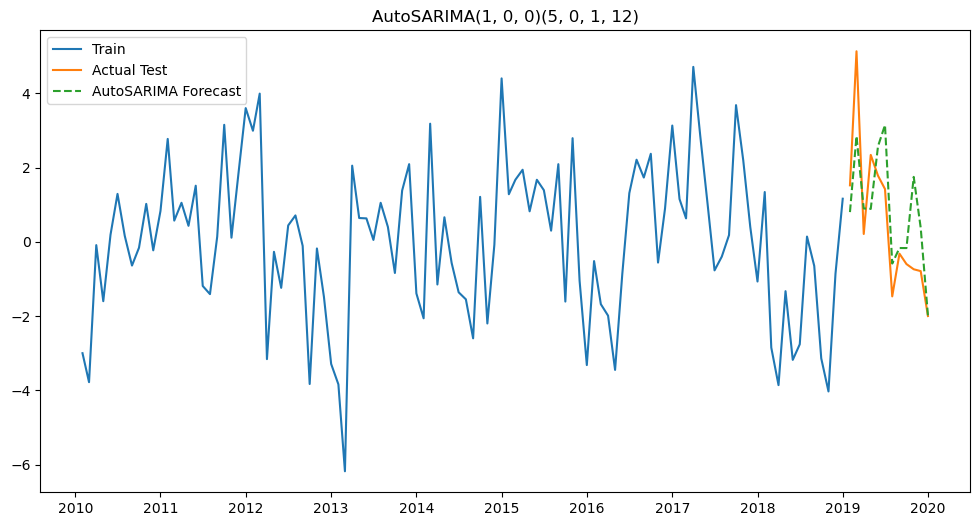

{'order': (1, 0, 0),
 'seasonal_order': (5, 0, 1, 12),
 'rmse': np.float64(1.3059232159326923),
 'mae': 1.06643105060087,
 'model': ARIMA(order=(1, 0, 0), scoring_args={}, seasonal_order=(5, 0, 1, 12),
       suppress_warnings=True),
 'forecast': date
 2019-02-01    0.799370
 2019-03-01    2.844089
 2019-04-01    0.897181
 2019-05-01    0.885072
 2019-06-01    2.569484
 2019-07-01    3.144393
 2019-08-01   -0.586590
 2019-09-01   -0.167952
 2019-10-01   -0.169065
 2019-11-01    1.747486
 2019-12-01    0.375165
 2020-01-01   -1.984400
 dtype: float64,
 'test': date
 2019-02-01    1.52
 2019-03-01    5.13
 2019-04-01    0.21
 2019-05-01    2.34
 2019-06-01    1.78
 2019-07-01    1.42
 2019-08-01   -1.47
 2019-09-01   -0.32
 2019-10-01   -0.60
 2019-11-01   -0.74
 2019-12-01   -0.79
 2020-01-01   -2.00
 Name: t_seasdiff, dtype: float64}

In [21]:
auto_sarima_experiment(data_sd, target='t_seasdiff',forecast_window=12, no_windows=10, max_P=12, max_Q=12, max_p=12, max_q=12, m=12)